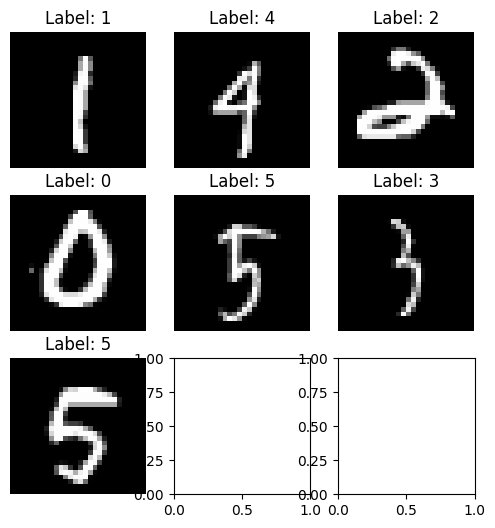

Image batch shape: torch.Size([64, 1, 28, 28])
Label batch shape: torch.Size([64])


In [ ]:
import torch
import ssl
ssl._create_default_https_context = ssl._create_unverified_context
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

transform = transforms.Compose([
    transforms.ToTensor(),              # Convert images to PyTorch tensors
    transforms.Normalize((0.5,), (0.5,))  # Normalize with mean=0.5, std=0.5
])

# Download and load training and test datasets
trainset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
testset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Create data loaders for batching
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False)

# Get one batch of images
dataiter = iter(trainloader)
images, labels = next(dataiter)

# Display first 9 images
fig, axes = plt.subplots(3, 3, figsize=(6,6))
for i in range(7):
    ax = axes[i//3, i%3]
    ax.imshow(images[i].squeeze(), cmap='gray')
    ax.set_title(f"Label: {labels[i].item()}")
    ax.axis('off')
plt.show()

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)